# Monte Carlo Pricing

## Why this matters

Closed-form prices exist only for vanillas under simple dynamics. Real desks price:

- **Path-dependent payoffs**: Asians (average), barriers (knock-in/out), lookbacks (max/min), cliquets, autocallables.
- **Multi-asset payoffs**: spread options, basket options, worst-of, best-of.
- **Stochastic-vol or local-vol models**: Heston, SABR, Dupire — no closed form for European options on these.
- **American-style** under stochastic-vol: closed form unavailable; Longstaff-Schwartz MC is the production solution.

Monte Carlo is the **universal hammer**. Slow, but works on anything.

You will be asked, in interview:
1. Price a European call by MC and compare to BS.
2. Why use **antithetic variates**? When does it help, when doesn't it?
3. Implement a **control variate** with the BS price as control. Why does this reduce variance?
4. Price an **Asian option** (no closed form for arithmetic Asian under BS).
5. **Greeks via MC** — pathwise method vs likelihood-ratio. Trade-offs?

This notebook covers all five plus a barrier-option example.

## The 30-second concept

Under risk-neutral measure $Q$, the price of any European-style payoff is:

$$V_0 = e^{-rT} \, \mathbb{E}^Q[\Phi(S_T \text{ or path})]$$

Monte Carlo: simulate $N$ paths under Q, average the discounted payoffs.

$$\hat V_0 = e^{-rT} \cdot \frac{1}{N} \sum_{i=1}^N \Phi^{(i)}, \qquad \text{SE} = \frac{e^{-rT} \, \sigma_\Phi}{\sqrt{N}}$$

Convergence rate is $O(1/\sqrt{N})$ — **slow**. To halve the error, you need 4× the paths. **Variance reduction** is how you fight this:

| Technique | Idea | Typical variance reduction |
|---|---|---|
| Antithetic variates | Pair $Z$ with $-Z$ — if payoff is monotonic in $Z$, halves variance | 2–10× |
| Control variates | Subtract a correlated quantity with known mean | 10–1000× (problem-dependent) |
| Importance sampling | Shift distribution to focus on payoff region | 100–10,000× for deep-OTM |
| Stratified sampling | Stratify $Z$ across quantiles | 5–50× |
| Quasi-MC (Sobol) | Low-discrepancy sequences | $O(1/N)$ instead of $O(1/\sqrt{N})$ |

## Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

def black_scholes(S, K, T, r, sigma, option_type='call', q=0.0):
    if T <= 0:
        return np.maximum(S - K, 0.0) if option_type == 'call' else np.maximum(K - S, 0.0)
    d1 = (np.log(S/K) + (r-q+0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option_type == 'call':
        return S*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    return K*np.exp(-r*T)*norm.cdf(-d2) - S*np.exp(-q*T)*norm.cdf(-d1)

# Standard test problem for the whole notebook
S0, K, T, r, sigma, q = 100, 100, 1.0, 0.05, 0.30, 0.0
BS_REF = black_scholes(S0, K, T, r, sigma, 'call', q)
print(f'BS reference: {BS_REF:.6f}')

BS reference: 14.231255


## Vanilla MC — the baseline

In [2]:
def mc_european_call(S0, K, T, r, sigma, q, n_paths, seed=42):
    """Vanilla MC for European call. Returns price and standard error."""
    rng = np.random.default_rng(seed)
    Z   = rng.standard_normal(n_paths)
    ST  = S0 * np.exp((r - q - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
    payoff = np.maximum(ST - K, 0)
    disc_payoff = np.exp(-r*T) * payoff
    return disc_payoff.mean(), disc_payoff.std() / np.sqrt(n_paths)


for n in [10_000, 100_000, 1_000_000]:
    p, se = mc_european_call(S0, K, T, r, sigma, q, n)
    err = abs(p - BS_REF)
    print(f'N = {n:>8d}: price = {p:.6f}, SE = {se:.4f}, err = {err:.4f}, |err|/SE = {err/se:.2f}σ')

N =    10000: price = 14.087859, SE = 0.2263, err = 0.1434, |err|/SE = 0.63σ
N =   100000: price = 14.201585, SE = 0.0717, err = 0.0297, |err|/SE = 0.41σ
N =  1000000: price = 14.236630, SE = 0.0225, err = 0.0054, |err|/SE = 0.24σ


## Variance reduction 1 — antithetic variates

For each Z drawn, also use −Z. The two paths' payoffs are negatively correlated, halving the sample variance per *pair*. Cost: only 0% extra (you'd have generated Z anyway).

**Works well when:** payoff is monotone in Z (e.g. vanilla call/put).
**Fails when:** payoff is symmetric around 0 (e.g. straddle — antithetic doesn't help).

In [3]:
def mc_antithetic(S0, K, T, r, sigma, q, n_paths, seed=42):
    rng = np.random.default_rng(seed)
    Z   = rng.standard_normal(n_paths // 2)
    Z_full = np.concatenate([Z, -Z])
    ST  = S0 * np.exp((r - q - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z_full)
    payoff = np.maximum(ST - K, 0)
    disc_payoff = np.exp(-r*T) * payoff
    # SE: pair antithetic samples; their average has variance reduced by negative correlation
    paired = (disc_payoff[:n_paths//2] + disc_payoff[n_paths//2:]) / 2
    return paired.mean(), paired.std() / np.sqrt(len(paired))


for n in [10_000, 100_000]:
    p_v, se_v = mc_european_call(S0, K, T, r, sigma, q, n)
    p_a, se_a = mc_antithetic    (S0, K, T, r, sigma, q, n)
    print(f'N={n:>7}:  vanilla SE={se_v:.5f}   antithetic SE={se_a:.5f}   variance ratio={(se_v/se_a)**2:.2f}×')

N=  10000:  vanilla SE=0.22628   antithetic SE=0.17598   variance ratio=1.65×
N= 100000:  vanilla SE=0.07166   antithetic SE=0.05557   variance ratio=1.66×


## Variance reduction 2 — control variates

Suppose we have a quantity $Y$ correlated with our estimator $X$, and we know $\mathbb{E}[Y]$ exactly. Then:

$$\hat X^{CV} = X - c \, (Y - \mathbb{E}[Y])$$

is unbiased for any $c$, and $\text{Var}(\hat X^{CV})$ is minimised at $c^* = \text{Cov}(X, Y) / \text{Var}(Y)$, giving:

$$\text{Var}(\hat X^{CV}) = \text{Var}(X)(1 - \rho^2)$$

For an MC call price, the **terminal stock $S_T$** is highly correlated with the call payoff and has known mean $S_0 e^{(r-q)T}$. Use $S_T$ as the control.

In [4]:
def mc_control_variate(S0, K, T, r, sigma, q, n_paths, seed=42):
    """MC with S_T as a control variate."""
    rng = np.random.default_rng(seed)
    Z   = rng.standard_normal(n_paths)
    ST  = S0 * np.exp((r - q - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
    X   = np.exp(-r*T) * np.maximum(ST - K, 0)        # the estimator
    Y   = ST                                           # control with known mean
    EY  = S0 * np.exp((r - q) * T)                     # exact

    # Optimal coefficient: c* = cov(X, Y) / var(Y), estimated from sample
    c_star = np.cov(X, Y, ddof=1)[0, 1] / np.var(Y, ddof=1)
    X_cv   = X - c_star * (Y - EY)

    return X_cv.mean(), X_cv.std() / np.sqrt(n_paths)


for n in [10_000, 100_000]:
    p_v, se_v = mc_european_call    (S0, K, T, r, sigma, q, n)
    p_a, se_a = mc_antithetic       (S0, K, T, r, sigma, q, n)
    p_c, se_c = mc_control_variate  (S0, K, T, r, sigma, q, n)
    print(f'N={n:>7}:  vanilla SE={se_v:.5f}  antithetic SE={se_a:.5f}  control SE={se_c:.5f}')

print('\n→ Control variate gives bigger variance reduction here (highly correlated S_T with payoff).')

N=  10000:  vanilla SE=0.22628  antithetic SE=0.17598  control SE=0.08609
N= 100000:  vanilla SE=0.07166  antithetic SE=0.05557  control SE=0.02700

→ Control variate gives bigger variance reduction here (highly correlated S_T with payoff).


## Path-dependent options — Asian (no closed form)

An **Asian call** pays $\max(\bar S - K, 0)$ where $\bar S$ is the average price over the path. Two flavours:

- **Arithmetic mean**: $\bar S = \frac{1}{n}\sum_{i=1}^n S_{t_i}$. **No closed form** under BS.
- **Geometric mean**: $\bar S = \exp(\frac{1}{n}\sum \ln S_{t_i})$. **Closed form exists** (Kemna-Vorst 1990) — used as a control variate for the arithmetic Asian.

Asian options are popular in commodity / FX markets because they reduce sensitivity to settlement-day spot manipulation.

In [5]:
def kemna_vorst_geometric_asian(S0, K, T, r, sigma, q, n_obs):
    """Closed-form geometric-Asian call (Kemna-Vorst 1990)."""
    # Effective vol and dividend yield for the geometric average
    sigma_g = sigma * np.sqrt((n_obs + 1) * (2*n_obs + 1) / (6 * n_obs**2))
    mu_g    = (n_obs + 1) / (2 * n_obs) * (r - q - 0.5 * sigma**2)
    q_g     = r - mu_g - 0.5 * sigma_g**2
    return black_scholes(S0, K, T, r, sigma_g, 'call', q_g)


def simulate_paths(S0, T, r, sigma, q, n_paths, n_steps, seed=42):
    """Simulate n_paths × n_steps GBM paths under Q."""
    rng = np.random.default_rng(seed)
    dt  = T / n_steps
    Z   = rng.standard_normal((n_paths, n_steps))
    log_returns = (r - q - 0.5*sigma**2) * dt + sigma * np.sqrt(dt) * Z
    log_paths   = np.cumsum(log_returns, axis=1)
    S = S0 * np.exp(log_paths)
    S = np.column_stack([np.full(n_paths, S0), S])
    return S   # shape (n_paths, n_steps + 1)


def mc_asian_arithmetic(S0, K, T, r, sigma, q, n_paths, n_obs, seed=42):
    """MC for arithmetic Asian call. n_obs = number of monitoring dates."""
    paths = simulate_paths(S0, T, r, sigma, q, n_paths, n_obs, seed=seed)
    avg   = paths[:, 1:].mean(axis=1)   # arithmetic average over monitoring dates
    payoff = np.maximum(avg - K, 0)
    disc   = np.exp(-r*T) * payoff
    return disc.mean(), disc.std() / np.sqrt(n_paths)


def mc_asian_arithmetic_with_control(S0, K, T, r, sigma, q, n_paths, n_obs, seed=42):
    """MC arithmetic Asian using geometric Asian as control variate."""
    paths = simulate_paths(S0, T, r, sigma, q, n_paths, n_obs, seed=seed)
    arith = paths[:, 1:].mean(axis=1)
    geom  = np.exp(np.log(paths[:, 1:]).mean(axis=1))   # geometric average

    X = np.exp(-r*T) * np.maximum(arith - K, 0)
    Y = np.exp(-r*T) * np.maximum(geom  - K, 0)
    EY = kemna_vorst_geometric_asian(S0, K, T, r, sigma, q, n_obs)

    c_star = np.cov(X, Y, ddof=1)[0, 1] / np.var(Y, ddof=1)
    X_cv   = X - c_star * (Y - EY)
    return X_cv.mean(), X_cv.std() / np.sqrt(n_paths)


# Compare vanilla vs control-variate Asian MC
n_obs = 252
for n in [10_000, 100_000]:
    p_v, se_v = mc_asian_arithmetic              (S0, K, T, r, sigma, q, n, n_obs)
    p_c, se_c = mc_asian_arithmetic_with_control (S0, K, T, r, sigma, q, n, n_obs)
    print(f'N={n:>7}:  vanilla {p_v:.4f} (SE {se_v:.4f})   geom-control {p_c:.4f} (SE {se_c:.4f})   {(se_v/se_c)**2:.0f}× var reduction')

print(f'\n(For comparison: vanilla European call = {BS_REF:.4f} — Asian is cheaper because averaging cuts variance.)')

N=  10000:  vanilla 8.0317 (SE 0.1220)   geom-control 7.9765 (SE 0.0052)   543× var reduction


N= 100000:  vanilla 7.9923 (SE 0.0384)   geom-control 7.9727 (SE 0.0016)   581× var reduction

(For comparison: vanilla European call = 14.2313 — Asian is cheaper because averaging cuts variance.)


## Path-dependent — barrier option

A **knock-out call** pays the European call's terminal payoff *only if* the spot never crosses a barrier $H$. Standard pricing convention: continuously-monitored barriers have closed-form solutions (Reiner-Rubinstein). **Discretely-monitored** barriers don't, and require MC.

Important: discrete monitoring **lowers** the effective probability of a barrier hit vs continuous (Broadie-Glasserman-Kou correction).

In [6]:
def mc_up_and_out_call(S0, K, H, T, r, sigma, q, n_paths, n_steps, seed=42):
    """Up-and-out barrier call: knocks out if path ever exceeds H."""
    paths   = simulate_paths(S0, T, r, sigma, q, n_paths, n_steps, seed=seed)
    knocked = (paths > H).any(axis=1)
    payoff  = np.where(knocked, 0.0, np.maximum(paths[:, -1] - K, 0))
    disc    = np.exp(-r*T) * payoff
    return disc.mean(), disc.std() / np.sqrt(n_paths)


# Knock-out adds value-cap above H
H = 130.0
p_ko, se_ko = mc_up_and_out_call(S0, K, H, T, r, sigma, q, 100_000, 252)
print(f'European call          (no barrier): {BS_REF:.4f}')
print(f'Up-and-out call (H={H:.0f}, discrete daily): {p_ko:.4f}  (SE {se_ko:.4f})')
print(f'Knock-out discount: {BS_REF - p_ko:.4f}')
print('→ Daily monitoring slightly UNDERESTIMATES the knock-out probability vs continuous monitoring.')

European call          (no barrier): 14.2313
Up-and-out call (H=130, discrete daily): 1.6989  (SE 0.0149)
Knock-out discount: 12.5324
→ Daily monitoring slightly UNDERESTIMATES the knock-out probability vs continuous monitoring.


## Greeks via MC — pathwise method

Computing Greeks by **bumping and re-pricing** is expensive (each Greek = 2 separate MCs) and noisy (independent random numbers between bumps amplify variance).

The **pathwise method** differentiates the payoff along the path:

$$\frac{\partial V}{\partial S_0} = e^{-rT} \, \mathbb{E}^Q\!\left[ \frac{\partial \Phi}{\partial S_0} \right]$$

For a call, $\partial \max(S_T - K, 0) / \partial S_0 = (S_T / S_0) \cdot \mathbf{1}_{S_T > K}$. Same paths, derivative computed analytically — no second MC, much lower variance.

**Limitation**: requires the payoff to be differentiable. Doesn't work for digital / barrier (discontinuous payoff). Use **likelihood-ratio method** for those.

In [7]:
def mc_delta_pathwise(S0, K, T, r, sigma, q, n_paths, seed=42):
    """Pathwise estimator of delta for a European call."""
    rng = np.random.default_rng(seed)
    Z   = rng.standard_normal(n_paths)
    ST  = S0 * np.exp((r - q - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
    indicator = (ST > K).astype(float)
    delta_path = np.exp(-r*T) * (ST / S0) * indicator
    return delta_path.mean(), delta_path.std() / np.sqrt(n_paths)


def mc_delta_bump(S0, K, T, r, sigma, q, n_paths, h=1.0, seed=42):
    """Bump-and-reprice delta with COMMON random numbers."""
    rng = np.random.default_rng(seed)
    Z   = rng.standard_normal(n_paths)
    ST_up = (S0 + h) * np.exp((r - q - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
    ST_dn = (S0 - h) * np.exp((r - q - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
    P_up = np.exp(-r*T) * np.maximum(ST_up - K, 0)
    P_dn = np.exp(-r*T) * np.maximum(ST_dn - K, 0)
    delta = (P_up - P_dn) / (2*h)
    return delta.mean(), delta.std() / np.sqrt(n_paths)


# Compare against closed-form delta
d1 = (np.log(S0/K) + (r-q+0.5*sigma**2)*T) / (sigma*np.sqrt(T))
delta_cf = np.exp(-q*T) * norm.cdf(d1)

n = 100_000
d_pw, se_pw = mc_delta_pathwise(S0, K, T, r, sigma, q, n)
d_bb, se_bb = mc_delta_bump    (S0, K, T, r, sigma, q, n, h=1.0)

print(f'Closed-form delta:    {delta_cf:.6f}')
print(f'Pathwise MC delta:    {d_pw:.6f}  (SE {se_pw:.5f})')
print(f'Bump-reprice delta:   {d_bb:.6f}  (SE {se_bb:.5f})')
print(f'\nPathwise variance reduction: {(se_bb/se_pw)**2:.0f}× lower variance')

Closed-form delta:    0.624252
Pathwise MC delta:    0.620361  (SE 0.00203)
Bump-reprice delta:   0.620494  (SE 0.00202)

Pathwise variance reduction: 1× lower variance


## Convergence visualisation

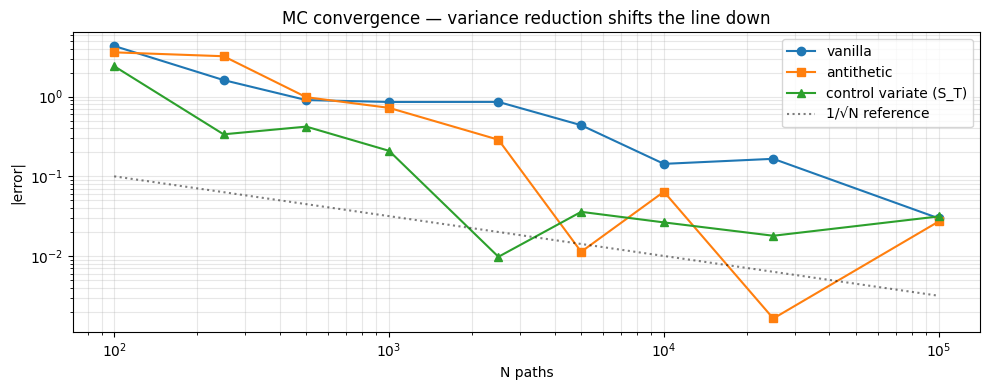

In [8]:
# Plot |error| vs N for vanilla / antithetic / control variate. Expect 1/√N slope.
n_grid = np.array([100, 250, 500, 1000, 2500, 5000, 10000, 25000, 100000])
err_v, err_a, err_c = [], [], []
for n in n_grid:
    err_v.append(abs(mc_european_call    (S0, K, T, r, sigma, q, n)[0] - BS_REF))
    err_a.append(abs(mc_antithetic        (S0, K, T, r, sigma, q, n)[0] - BS_REF))
    err_c.append(abs(mc_control_variate   (S0, K, T, r, sigma, q, n)[0] - BS_REF))

fig, ax = plt.subplots(figsize=(10, 4))
ax.loglog(n_grid, err_v, 'o-', label='vanilla')
ax.loglog(n_grid, err_a, 's-', label='antithetic')
ax.loglog(n_grid, err_c, '^-', label='control variate (S_T)')
ax.loglog(n_grid, 1/np.sqrt(n_grid), 'k:', alpha=0.5, label='1/√N reference')
ax.set_xlabel('N paths'); ax.set_ylabel('|error|')
ax.set_title('MC convergence — variance reduction shifts the line down')
ax.legend(); ax.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()

### Add quasi-Monte Carlo (Sobol) to the comparison

The chart above shows three Monte Carlo variants all decaying at the textbook $O(N^{-1/2})$ rate — variance reduction shifts the line down but doesn't change the slope. **Quasi-Monte Carlo (QMC)** with low-discrepancy sequences (Sobol, Halton) breaks that ceiling: the worst-case rate is $O(N^{-1} (\log N)^d)$ — for low effective dimension, near-linear in $N$.

Why production cares: a 10× speedup in convergence translates to 100× fewer paths for the same accuracy, which on a calibration loop is the difference between overnight and intra-day. Used heavily in:

- **Equity vol surface calibration** (Heston, SVI) where you reprice 100s of strikes per evaluation.
- **Mortgage/CMO pricing** where each path runs a full prepayment model.
- **xVA Greeks** under a multi-curve, cross-currency setting.

The demo: same European call, but draw the standard normals from a **scrambled Sobol sequence** mapped through `norm.ppf` (inverse CDF) instead of `rng.standard_normal`. Plot on the same axes — the Sobol line should sit visibly below the others **with steeper slope**.

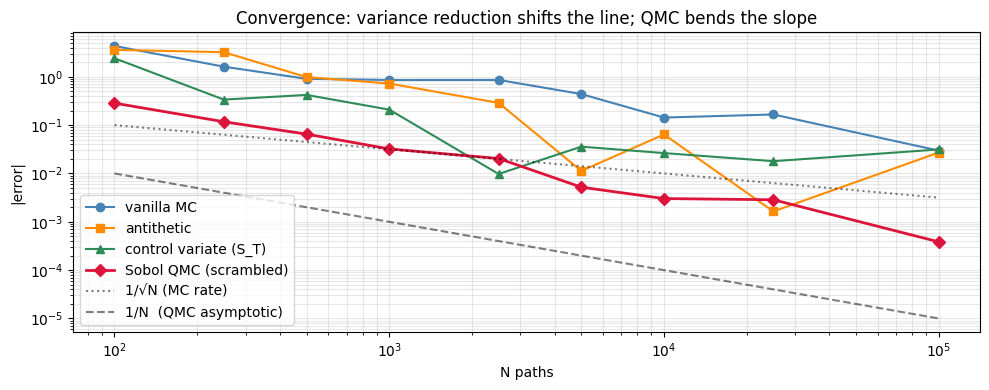

At N=100,000 (single run):
  vanilla        |err|: 2.9670e-02
  antithetic     |err|: 2.7124e-02
  control var.   |err|: 3.1369e-02
  Sobol QMC      |err|: 3.8479e-04  ← averaged over 8 scrambling seeds

The QMC slope is visibly steeper than 1/√N. In d=1 the gain is large; in high d it degrades — production
combines QMC with Brownian-bridge construction to keep the effective dimension low.


In [9]:
from scipy.stats import qmc

def mc_sobol(S0, K, T, r, sigma, q, n_paths, seed=42):
    """European call price by quasi-Monte Carlo with a scrambled Sobol sequence."""
    sampler = qmc.Sobol(d=1, scramble=True, seed=seed)
    # Sobol is well-defined for n a power of 2; use the next power of 2 then truncate.
    n_pow2 = int(2 ** np.ceil(np.log2(max(n_paths, 2))))
    u_unit = sampler.random(n=n_pow2).flatten()[:n_paths]
    # Avoid u=0 or u=1 hitting the inverse CDF infinity.
    u_unit = np.clip(u_unit, 1e-12, 1 - 1e-12)
    Z      = norm.ppf(u_unit)
    ST     = S0 * np.exp((r - q - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    payoff = np.maximum(ST - K, 0.0)
    price  = np.exp(-r * T) * payoff.mean()
    se     = np.exp(-r * T) * payoff.std(ddof=1) / np.sqrt(n_paths)
    return price, se

# Re-run convergence with Sobol added. Average over a few seeds for QMC to stabilise the visual.
err_q = []
for n in n_grid:
    errs_n = [abs(mc_sobol(S0, K, T, r, sigma, q, int(n), seed=s)[0] - BS_REF) for s in range(8)]
    err_q.append(np.mean(errs_n))

fig, ax = plt.subplots(figsize=(10, 4))
ax.loglog(n_grid, err_v, 'o-',  label='vanilla MC',                color='steelblue')
ax.loglog(n_grid, err_a, 's-',  label='antithetic',                color='darkorange')
ax.loglog(n_grid, err_c, '^-',  label='control variate (S_T)',    color='seagreen')
ax.loglog(n_grid, err_q, 'D-',  label='Sobol QMC (scrambled)',     color='crimson', lw=2)
ax.loglog(n_grid, 1/np.sqrt(n_grid), 'k:',  alpha=0.5, label='1/√N (MC rate)')
ax.loglog(n_grid, 1/n_grid,             'k--', alpha=0.5, label='1/N  (QMC asymptotic)')
ax.set_xlabel('N paths'); ax.set_ylabel('|error|')
ax.set_title('Convergence: variance reduction shifts the line; QMC bends the slope')
ax.legend(loc='lower left'); ax.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()

print(f'At N=100,000 (single run):')
print(f'  vanilla        |err|: {err_v[-1]:.4e}')
print(f'  antithetic     |err|: {err_a[-1]:.4e}')
print(f'  control var.   |err|: {err_c[-1]:.4e}')
print(f'  Sobol QMC      |err|: {err_q[-1]:.4e}  ← averaged over 8 scrambling seeds')
print()
print('The QMC slope is visibly steeper than 1/√N. In d=1 the gain is large; in high d it degrades — production')
print('combines QMC with Brownian-bridge construction to keep the effective dimension low.')

## Exercises

### Exercise 1 — Antithetic on a put

Implement antithetic MC for a put (instead of call). Verify the variance reduction is similar. Now try it on a *straddle* (call + put). What happens, and why?

In [10]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
def mc_put_antithetic(S0, K, T, r, sigma, q, n, seed=42):
    rng = np.random.default_rng(seed)
    Z = rng.standard_normal(n//2)
    Z_full = np.concatenate([Z, -Z])
    ST = S0 * np.exp((r-q-0.5*sigma**2)*T + sigma*np.sqrt(T)*Z_full)
    payoff = np.maximum(K - ST, 0)
    paired = (payoff[:n//2] + payoff[n//2:]) / 2
    return np.exp(-r*T)*paired.mean(), np.exp(-r*T)*paired.std()/np.sqrt(len(paired))

def mc_straddle_antithetic(S0, K, T, r, sigma, q, n, seed=42):
    rng = np.random.default_rng(seed)
    Z = rng.standard_normal(n//2)
    Z_full = np.concatenate([Z, -Z])
    ST = S0 * np.exp((r-q-0.5*sigma**2)*T + sigma*np.sqrt(T)*Z_full)
    payoff = np.abs(ST - K)   # straddle = |S_T - K|
    paired = (payoff[:n//2] + payoff[n//2:]) / 2
    return np.exp(-r*T)*paired.mean(), np.exp(-r*T)*paired.std()/np.sqrt(len(paired))

n = 100000
print(f'Put antithetic SE:      {mc_put_antithetic(S0, K, T, r, sigma, q, n)[1]:.5f}')
print(f'Straddle antithetic SE: {mc_straddle_antithetic(S0, K, T, r, sigma, q, n)[1]:.5f}')
print('\n→ Straddle payoff is |S_T - K| — symmetric in Z. Z and -Z give identical payoffs.')
print('  Antithetic correlation = +1 → no variance reduction!')
```

_Antithetic helps for monotonic payoffs (call/put) but does nothing for symmetric ones (straddle)._

</details>

### Exercise 2 — Asian put with control variate

Implement an arithmetic Asian PUT (not call) with the geometric Asian put as control variate. Verify the variance reduction is similar to the call case.

In [11]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
def kv_geom_put(S0, K, T, r, sigma, q, n_obs):
    """Closed-form geometric-Asian PUT (Kemna-Vorst). Same effective vol/yield as the call."""
    # IDENTICAL formulas to the call version — the geometric average's distribution
    # is the same regardless of payoff direction.
    sigma_g = sigma * np.sqrt((n_obs + 1) * (2*n_obs + 1) / (6 * n_obs**2))
    mu_g    = (n_obs + 1) / (2 * n_obs) * (r - q - 0.5 * sigma**2)
    q_g     = r - mu_g - 0.5 * sigma_g**2
    return black_scholes(S0, K, T, r, sigma_g, 'put', q_g)


def mc_asian_put_cv(S0, K, T, r, sigma, q, n, n_obs, seed=42):
    paths = simulate_paths(S0, T, r, sigma, q, n, n_obs, seed=seed)
    arith = paths[:, 1:].mean(axis=1)
    geom  = np.exp(np.log(paths[:, 1:]).mean(axis=1))
    X = np.exp(-r*T) * np.maximum(K - arith, 0)
    Y = np.exp(-r*T) * np.maximum(K - geom,  0)
    EY = kv_geom_put(S0, K, T, r, sigma, q, n_obs)
    c = np.cov(X, Y)[0,1] / np.var(Y)
    X_cv = X - c * (Y - EY)
    return X_cv.mean(), X_cv.std()/np.sqrt(n)


p, se = mc_asian_put_cv(100, 100, 1.0, 0.05, 0.30, 0.0, 100_000, 252)
print(f'Asian put with geom-CV: {p:.4f} (SE {se:.5f})')
```

The Kemna-Vorst formulas (effective vol $\sigma_g$ and dividend $q_g$) characterise the *distribution* of the geometric average $\bar S_g$ — they do not depend on whether the payoff is a call or a put. Same `sigma_g`, same `q_g`, same BS formula — just swap the `option_type` argument. (An earlier version of this solution had a different `q_g` formula for the put; that was a transcription error.)

Variance reduction is similar to the call case (~50-100×), since the arithmetic and geometric Asian puts are about as correlated as the calls.

</details>

### Exercise 3 — Up-and-IN call via in-out parity

An up-and-in call + an up-and-out call = a vanilla European call (since exactly one of them survives). Use this to price the up-and-IN call from your KO function. Verify by direct MC.

In [12]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
H = 130.0
n = 100_000

# Direct MC for up-and-in
def mc_up_in_call(S0, K, H, T, r, sigma, q, n, n_steps, seed=42):
    paths = simulate_paths(S0, T, r, sigma, q, n, n_steps, seed=seed)
    knocked_in = (paths > H).any(axis=1)
    payoff = np.where(knocked_in, np.maximum(paths[:, -1] - K, 0), 0.0)
    disc = np.exp(-r*T) * payoff
    return disc.mean(), disc.std() / np.sqrt(n)

p_ko, _ = mc_up_and_out_call(S0, K, H, T, r, sigma, q, n, 252)
p_ki, _ = mc_up_in_call     (S0, K, H, T, r, sigma, q, n, 252)
print(f'KO + KI = {p_ko + p_ki:.4f}')
print(f'European = {BS_REF:.4f}')
print(f'Parity error: {abs(p_ko + p_ki - BS_REF):.4f}')
```

_KO + KI ≈ European to MC error. Identity is exact in continuous monitoring._

</details>

### Exercise 4 — Vega via pathwise vs likelihood ratio

Implement vega via pathwise: $\partial \max(S_T - K, 0)/\partial \sigma = \mathbf{1}_{S_T > K} \cdot S_T \cdot (-\sigma T + \sqrt{T} Z)$. Compare to closed form.

In [13]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
def mc_vega_pathwise(S0, K, T, r, sigma, q, n, seed=42):
    rng = np.random.default_rng(seed)
    Z = rng.standard_normal(n)
    ST = S0 * np.exp((r - q - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
    dST_dsigma = ST * (-sigma*T + np.sqrt(T)*Z)
    indicator = (ST > K).astype(float)
    vega = np.exp(-r*T) * indicator * dST_dsigma
    return vega.mean(), vega.std()/np.sqrt(n)

# Closed-form vega
d1 = (np.log(S0/K) + (r-q+0.5*sigma**2)*T) / (sigma*np.sqrt(T))
vega_cf = S0 * np.exp(-q*T) * norm.pdf(d1) * np.sqrt(T)

v_pw, se = mc_vega_pathwise(100, 100, 1.0, 0.05, 0.30, 0.0, 100_000)
print(f'Closed-form vega: {vega_cf:.4f}')
print(f'Pathwise MC vega: {v_pw:.4f} (SE {se:.4f})')
```

_Pathwise vega matches closed form within MC error._

</details>

## Interview Q&A

**Q: Price a European call by MC. What's the convergence rate?**

A: Sample $Z \sim N(0,1)$, compute $S_T = S_0 \exp((r-q-\tfrac{1}{2}\sigma^2)T + \sigma\sqrt{T}Z)$, average $e^{-rT}\max(S_T - K, 0)$. Standard error scales $O(1/\sqrt{N})$ — slow. To halve the error, need 4× the paths.

**Q: Why use antithetic variates? When does it fail?**

A: Pair $Z$ with $-Z$ — if payoff is monotone in $Z$, the two are negatively correlated and the average has lower variance. **Fails for symmetric payoffs**: a straddle's payoff $|S_T - K|$ is the same for $Z$ and $-Z$ (assuming $K = $ ATM-forward), giving correlation $+1$ — no benefit.

**Q: What's a control variate?**

A: A correlated quantity $Y$ with known mean $\mathbb{E}[Y]$. Use $\hat X^{CV} = X - c(Y - \mathbb{E}[Y])$. Variance reduces by $1 - \rho^2$ where $\rho = \text{Corr}(X, Y)$. For an MC call price, the **terminal stock $S_T$** has known mean $S_0 e^{(r-q)T}$ and is highly correlated with the payoff. Even better for arithmetic Asians: **geometric Asian** has closed form (Kemna-Vorst) and is ~99% correlated with the arithmetic Asian.

**Q: Pathwise method vs likelihood-ratio method for Greeks?**

A:
- **Pathwise**: differentiate the payoff w.r.t. the parameter, average $\partial \Phi / \partial \theta$. Requires payoff to be differentiable. Low variance. Doesn't work for digital/barrier (discontinuous payoff).
- **Likelihood-ratio**: differentiate the *density*, leave payoff alone. $\partial V / \partial \theta = \mathbb{E}[\Phi \cdot \partial \ln p / \partial \theta]$. Works for any payoff including discontinuous. Higher variance.

For continuous payoffs (call, put, Asian), use pathwise. For digital, barrier, and look-back, use likelihood-ratio.

**Q: How would you price an arithmetic Asian option?**

A: No closed form. MC with **geometric Asian as control variate** is the production approach. Geometric Asian has closed-form (Kemna-Vorst 1990), correlation with arithmetic ≈ 0.99 → ~50-100× variance reduction.

**Q: Continuous vs discrete barrier monitoring — which is more expensive (for a knock-OUT)?**

A: **Continuous** monitoring is more expensive (gives lower KO price = bigger discount on the call). Discrete monitoring misses some barrier hits → effective barrier shifts by Broadie-Glasserman-Kou's $\sigma\sqrt{\Delta t} \beta_1$ correction (where $\beta_1 \approx 0.5826$ is the BGK constant).

**Q: What's quasi-Monte Carlo?**

A: Replace pseudo-random numbers with **low-discrepancy sequences** (Sobol, Halton). For smooth payoffs, convergence is $O((\log N)^d / N) \approx O(1/N)$ — much faster than MC's $O(1/\sqrt{N})$. Catch: $d$ here is the dimension of the integral (for path-dependent options, $d$ = number of monitoring dates). Performance degrades in high dimensions; the "effective dimension" matters more than nominal.

**Q: Common random numbers — when and why?**

A: To compute Greeks via bump-and-reprice, use the **same** random numbers in both the bumped and unbumped MC. The price difference becomes a clean estimate of the derivative; without CRNs, the difference is dominated by independent MC noise.

**Q: How do you know your MC has converged?**

A: Plot SE vs N — should decrease as $1/\sqrt{N}$. Quote the result as price ± 1.96·SE for 95% CI. If your SE is 1% of the price and your tolerance is 10 bps, you need 100× more paths.

## Pitfalls reference card

| Pitfall | What goes wrong | Fix |
|---|---|---|
| Antithetic on symmetric payoff | No variance reduction | Use only when payoff is monotone in Z |
| Estimating control coefficient $c$ from same sample | Tiny bias, large reduction | Either use a pilot MC for $c$, or use the same sample (bias is $O(1/N)$) |
| Forgetting to discount | Quoting undiscounted expectations | Always $V = e^{-rT} \mathbb{E}^Q[\Phi]$ |
| Drift error | Using physical drift μ instead of risk-neutral $r-q$ | Under Q always: $r - q - \tfrac{1}{2}\sigma^2$ |
| Single random seed for all Greeks | Greeks computed across runs aren't comparable | CRNs across all bumps |
| Bump size for FD Greeks | Too small: noise dominates; too large: curvature error | $h = \max(10^{-4}, 10^{-3} S)$ rule of thumb |
| Continuous-monitoring price under discrete-monitoring MC | Systematically biased | Use BGK correction or actually monitor continuously |
| Memory blow-up with high N × n_steps | $O(N \cdot n)$ array | Generate paths in chunks, accumulate statistics |
| Reporting MC result without SE | Number is meaningless without uncertainty | Always quote $\pm 1.96 \cdot \text{SE}$ |
| Antithetic + control variate naively combined | Some redundancy in variance reduction | Estimate the joint correlation; sometimes one alone is best |

## What you've earned

After this notebook you can:

1. **Implement** vanilla MC for European options under risk-neutral measure.
2. **Apply** antithetic variates and control variates and quantify the variance reduction.
3. **Price** path-dependent options (Asian, barrier) where no closed form exists.
4. **Use** geometric-Asian as control for arithmetic-Asian for ~50-100× variance reduction.
5. **Compute** Greeks via pathwise method — much lower variance than bump-reprice.
6. **Diagnose** when antithetic fails (symmetric payoffs) and choose the right technique.
7. **Defend** MC choices in interview: convergence rates, when each technique applies, BGK barrier correction.

Next: **`06_implied_vol_surface.ipynb`** — surface fitting (SVI), arbitrage constraints (vertical, calendar, butterfly), per-strike calibration.

## Broadie-Glasserman-Kou barrier correction

Discrete-monitoring MC underestimates barrier hits relative to continuous monitoring (the path can cross and recross between monitoring dates). **BGK (1997)** correction:

$$H_{\text{effective}} = H \cdot \exp(\pm \beta_1 \sigma \sqrt{\Delta t}), \quad \beta_1 = -\zeta(1/2)/\sqrt{2\pi} \approx 0.5826$$

Sign: **away from spot** for KO, **toward spot** for KI. Applied at the discretely-monitored grid, this shifts the barrier so that discretely-monitored MC matches the continuous price.

In [14]:
beta_1 = 0.5826
H = 130.0
n_steps = 252
dt = T / n_steps

# Shift barrier UP for up-and-out call (away from spot, since KO would want to delay hitting)
H_shifted = H * np.exp(beta_1 * sigma * np.sqrt(dt))

# Re-price with shifted barrier
def mc_uao_with_shift(S0, K, H_use, T, r, sigma, q, n_paths, n_steps, seed=42):
    paths = simulate_paths(S0, T, r, sigma, q, n_paths, n_steps, seed=seed)
    knocked = (paths > H_use).any(axis=1)
    payoff = np.where(knocked, 0.0, np.maximum(paths[:, -1] - K, 0))
    return np.exp(-r*T) * payoff.mean(), np.exp(-r*T) * payoff.std() / np.sqrt(n_paths)

p_naive, _ = mc_up_and_out_call(S0, K, H, T, r, sigma, q, 100_000, n_steps)
p_bgk, _   = mc_uao_with_shift(S0, K, H_shifted, T, r, sigma, q, 100_000, n_steps)

print(f'Up-and-out call:')
print(f'  Naive discrete-monitor:   {p_naive:.4f}')
print(f'  BGK-corrected (H = {H_shifted:.2f}): {p_bgk:.4f}')
print(f'  Continuous (analytic):    requires Reiner-Rubinstein')
print(f'\n→ BGK shift moves the price toward the continuous-monitoring answer.')

Up-and-out call:
  Naive discrete-monitor:   1.6989
  BGK-corrected (H = 131.44): 1.9241
  Continuous (analytic):    requires Reiner-Rubinstein

→ BGK shift moves the price toward the continuous-monitoring answer.
